# Decision Tree & KNN – Day 4

## Objective
Train and compare Decision Tree and KNN models

## Decision Tree
- Tree-based model
- Makes decisions using rules
- Can overfit easily

## KNN (K-Nearest Neighbors)
- Distance-based model
- Finds nearest data points
- Sensitive to scaling

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [2]:
data = load_iris()

X = data.data
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

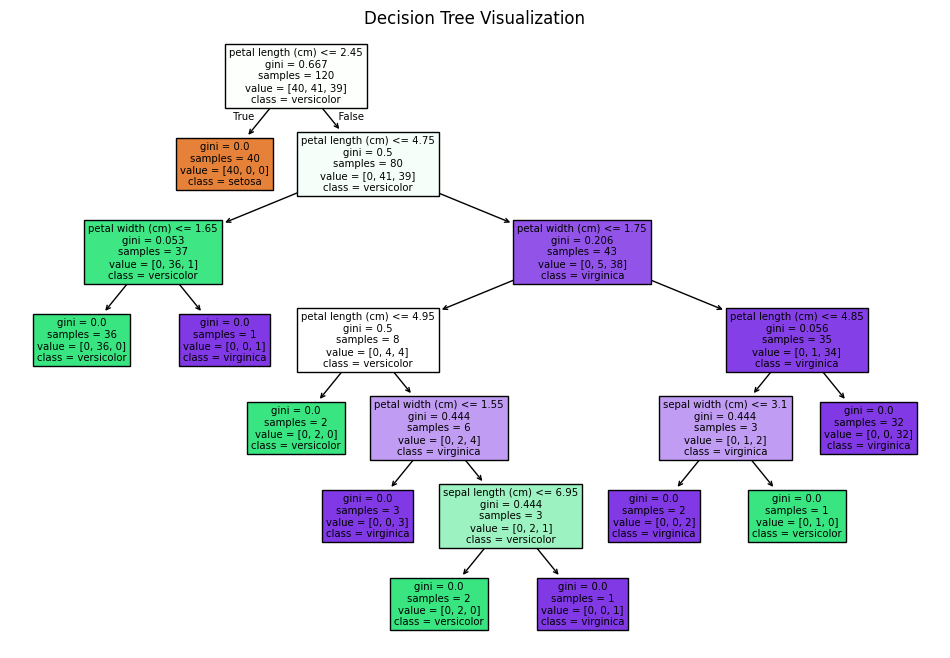

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(dt_model, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title("Decision Tree Visualization")
plt.show()

In [5]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

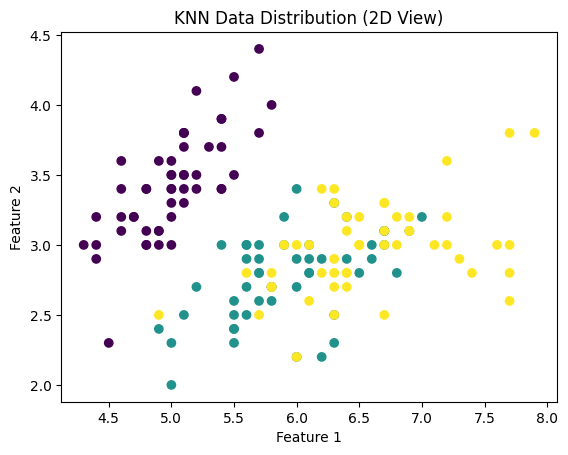

In [10]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Data Distribution (2D View)")
plt.show()

In [6]:
dt_acc = accuracy_score(y_test, dt_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("Decision Tree Accuracy:", dt_acc)
print("KNN Accuracy:", knn_acc)

Decision Tree Accuracy: 1.0
KNN Accuracy: 1.0


In [7]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "KNN"],
    "Accuracy": [dt_acc, knn_acc]
})

print(comparison)

           Model  Accuracy
0  Decision Tree       1.0
1            KNN       1.0


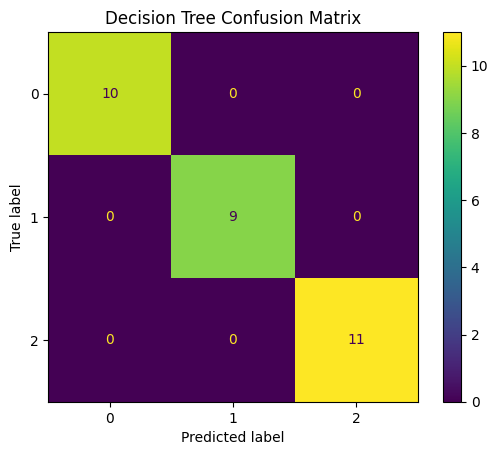

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

knn_scaled_pred = knn_scaled.predict(X_test_scaled)

print("KNN after scaling:", accuracy_score(y_test, knn_scaled_pred))

KNN after scaling: 1.0


## Summary

- Decision Tree is rule-based and easy to interpret
- KNN depends on distance and benefits from scaling
- Model performance varies depending on data